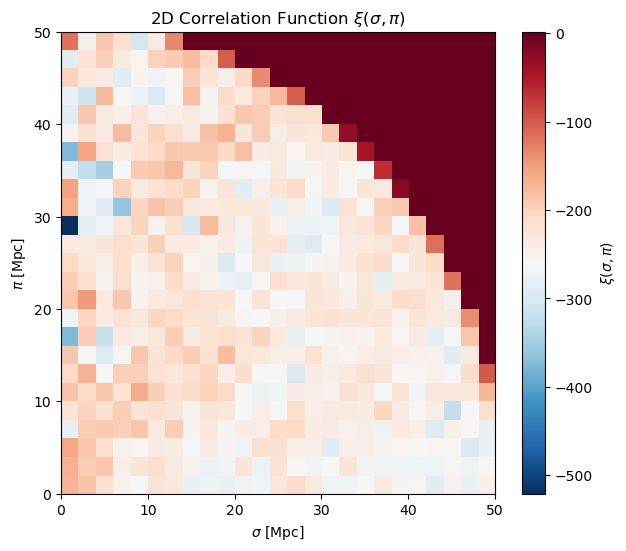

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.spatial import cKDTree
from multiprocessing import Pool, cpu_count

# -----------------------------
# 1. Cosmology
# -----------------------------
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# -----------------------------
# 2. Generate mock data
# -----------------------------
N_data = 50000  # large catalog
N_rand = 100000

ra_data = np.random.uniform(0, 360, N_data)
dec_data = np.degrees(np.arcsin(np.random.uniform(-1, 1, N_data)))
z_data = np.random.uniform(0, 0.3, N_data)
chi_data = cosmo.comoving_distance(z_data).value

ra_rand = np.random.uniform(0, 360, N_rand)
dec_rand = np.degrees(np.arcsin(np.random.uniform(-1, 1, N_rand)))
z_rand = np.random.uniform(0, 0.3, N_rand)
chi_rand = cosmo.comoving_distance(z_rand).value

# -----------------------------
# 3. Cartesian conversion
# -----------------------------
def sph2cart(ra, dec, chi):
    x = chi * np.cos(np.radians(dec)) * np.cos(np.radians(ra))
    y = chi * np.cos(np.radians(dec)) * np.sin(np.radians(ra))
    z = chi * np.sin(np.radians(dec))
    return x, y, z

x_data, y_data, z_data_cart = sph2cart(ra_data, dec_data, chi_data)
x_rand, y_rand, z_rand_cart = sph2cart(ra_rand, dec_rand, chi_rand)

# -----------------------------
# 4. Function to compute σ, π histogram for a chunk
# -----------------------------
def sigma_pi_hist_chunk(args):
    x_chunk, y_chunk, z_chunk, x_ref, y_ref, z_ref, bins, max_sep, auto = args
    tree_chunk = cKDTree(np.vstack([x_chunk, y_chunk, z_chunk]).T)
    tree_ref = tree_chunk if auto else cKDTree(np.vstack([x_ref, y_ref, z_ref]).T)
    
    if auto:
        pairs = tree_chunk.query_pairs(r=max_sep)
        i = np.array([p[0] for p in pairs])
        j = np.array([p[1] for p in pairs])
    else:
        pairs = tree_chunk.sparse_distance_matrix(tree_ref, max_sep, output_type='coo_matrix')
        i = pairs.row
        j = pairs.col
    
    dx = x_ref[j] - x_chunk[i]
    dy = y_ref[j] - y_chunk[i]
    dz = z_ref[j] - z_chunk[i]
    
    sigma = np.sqrt(dx**2 + dy**2)
    pi_val = np.abs(dz)
    
    H, _, _ = np.histogram2d(sigma, pi_val, bins=[bins, bins])
    return H

# -----------------------------
# 5. Parallel wrapper
# -----------------------------
def parallel_hist(x1, y1, z1, x2, y2, z2, bins, max_sep, auto=True):
    ncores = cpu_count()
    chunks = np.array_split(x1, ncores)
    chunks_y = np.array_split(y1, ncores)
    chunks_z = np.array_split(z1, ncores)
    
    args_list = [(chunks[i], chunks_y[i], chunks_z[i], x2, y2, z2, bins, max_sep, auto)
                 for i in range(ncores)]
    
    with Pool(ncores) as pool:
        results = pool.map(sigma_pi_hist_chunk, args_list)
    
    return sum(results)

# -----------------------------
# 6. Binning parameters
# -----------------------------
max_sep = 50.0
bin_size = 2.0
bins = np.arange(0, max_sep + bin_size, bin_size)

# -----------------------------
# 7. Compute histograms in parallel
# -----------------------------
H_dd = parallel_hist(x_data, y_data, z_data_cart,
                     x_data, y_data, z_data_cart, bins, max_sep, auto=True)
H_dr = parallel_hist(x_data, y_data, z_data_cart,
                     x_rand, y_rand, z_rand_cart, bins, max_sep, auto=False)
H_rr = parallel_hist(x_rand, y_rand, z_rand_cart,
                     x_rand, y_rand, z_rand_cart, bins, max_sep, auto=True)

# -----------------------------
# 8. Landy-Szalay estimator
# -----------------------------
xi = (H_dd - 2*H_dr + H_rr) / H_rr

# -----------------------------
# 9. Plot
# -----------------------------
plt.figure(figsize=(7,6))
plt.imshow(xi.T, origin='lower',
           extent=[bins[0], bins[-1], bins[0], bins[-1]],
           aspect='auto', cmap='RdBu_r')
plt.colorbar(label=r'$\xi(\sigma, \pi)$')
plt.xlabel(r'$\sigma$ [Mpc]')
plt.ylabel(r'$\pi$ [Mpc]')
plt.title(r'2D Correlation Function $\xi(\sigma, \pi)$')
plt.show()